# Neuroadaptive Haptics BCI results

- plots ERP from training condition for the four feedback conditions for all participants but the 'broken' participants with a color marking for the feature extraction time points
    - (compute MNE F-test for a main effect)
- descriptives of cross-validation, simulated chance level and plot interpolated ROC like in fastreach over all participants, print F1 score

In [44]:
import scipy.io as sio
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys, json

sys.path.append('/Users/lukasgehrke/Documents/publications/2022-CHI-neuroadaptive-haptics/neuro_haptics')
from bci_funcs import bandpass_filter_fft

pIDs = [7,9,10,11,12,14]

path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'
design = pd.read_csv(path + fname, delimiter=';')
design = design[['hapticProfile', 'id', 'bad_epoch']]

## ERPs

### Plot ERPs haptics contrast

In [ ]:
elecs = sio.loadmat(path+os.sep+'ERPs'+os.sep+'elecs.mat')['elecs']
elecs = [str(e[0]).replace('BrainVision RDA_', '') for e in elecs]
elecs = [e[2:-2] for e in elecs]

for elec in np.arange(0,64):

    df_all = pd.DataFrame()
    for id in range(7, 15):

        if id == 13 or id == 8:
            continue

        pID = 'sub-' + str(id)

        erp = sio.loadmat(path+os.sep+pID+os.sep+'erp.mat')['erp']
        erp = bandpass_filter_fft(erp, .1, 15, 250)

        # baseline correction
        baseline_time = np.arange(250, 262)
        erp = erp - erp[:,baseline_time,:].mean(axis=-2)[:,np.newaxis,:]
        erp = erp[elec,baseline_time[0]-25:baseline_time[0]+144,:]
        elec_erp = pd.DataFrame(erp).transpose()
        
        df_all = pd.concat([df_all, elec_erp], axis=0)

    # add design to df_all
    df_all = df_all.reset_index(drop=True)
    df_all = pd.concat([design, df_all], axis=1)

    # remove bad_epochs
    df_all = df_all[df_all['bad_epoch'] != 1]
    df_all = df_all.drop(columns='bad_epoch')

    # aggregate df_all by hapticProfile and id
    df_all = df_all.groupby(['hapticProfile', 'id']).mean().reset_index()

    # meldting the data
    df = df_all.melt(id_vars=['hapticProfile', 'id'], var_name='time', value_name='voltage').sort_values(by=['hapticProfile', 'id'])

    # time vector
    df['time'] = np.tile(np.arange(0, df_all.shape[1]-2), df_all.id.unique().shape[0] * df_all.hapticProfile.unique().shape[0])
    df['time'] = (df['time'] * 1/250 * 1000)-100
    # remove everything before > 600
    df = df[df['time'] < 576]

    with sns.plotting_context('paper', font_scale = 1.8):

        ### Create new plot
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
        fig.patch.set_alpha(1)

        sns.despine() #bottom=True, left=True

        # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
        sns.lineplot(x='time', y='voltage', hue='hapticProfile', data=df, ax=ax, errorbar='ci')
        # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (μV)')

        # xline at 0 with text label 's'
        ax.axvline(0, color='black', linestyle='--')
        ax.text(.1, 0, 'grab', fontsize=14, rotation=90)

        # yline at 0
        ax.axhline(0, color='black', linestyle='--')

        # get min y value
        ymin = df['voltage'].min()

        # Mark area of feature extraction with a grey background from ymin to ymax
        ax.axvspan(100, 576, ymin=0, ymax=.05, color='black', alpha=0.2) #, label='features')
        ax.axvspan(0, 50, ymin=0, ymax=.05, color='black', alpha=0.1) #, label='baseline')

        # move legend to the right and make smaller
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), )
        ax.legend(loc='upper left', fontsize=8)

        # save as eps
        plt.tight_layout()
        plt.savefig(path+os.sep+'ERPs'+os.sep+elecs[elec]+'_haptics.pdf', format='pdf', dpi=300)

### Plot ERPs median split by answerID/preference rating

In [ ]:
elecs = sio.loadmat(path+os.sep+'ERPs'+os.sep+'elecs.mat')['elecs']
elecs = [str(e[0]).replace('BrainVision RDA_', '') for e in elecs]
elecs = [e[2:-2] for e in elecs]

for elec in np.arange(0,64):

    df_all = pd.DataFrame()
    for id in range(7, 15):

        if id == 13 or id == 8:
            continue

        pID = 'sub-' + str(id)

        erp = sio.loadmat(path+os.sep+pID+os.sep+'erp.mat')['erp']
        erp = bandpass_filter_fft(erp, .1, 15, 250)

        # baseline correction
        baseline_time = np.arange(250, 262)
        erp = erp - erp[:,baseline_time,:].mean(axis=-2)[:,np.newaxis,:]
        erp = erp[elec,baseline_time[0]-25:baseline_time[0]+144,:]
        elec_erp = pd.DataFrame(erp).transpose()
        
        df_all = pd.concat([df_all, elec_erp], axis=0)

    # add design to df_all
    df_all = df_all.reset_index(drop=True)
    df_all = pd.concat([design, df_all], axis=1)

    # remove bad_epochs
    df_all = df_all[df_all['bad_epoch'] != 1]
    df_all = df_all.drop(columns='bad_epoch')

    # Calculate the median 'answerID' for each 'id'
    medians = df_all.groupby('id')['answerID'].median().reset_index()
    medians.columns = ['id', 'median_answerID']

    # Merge the medians back into the original DataFrame
    df_all = pd.merge(df_all, medians, on='id')

    # Create the 'Preference' column based on the median
    df_all['Preference'] = df_all.apply(lambda row: 'high' if row['answerID'] > row['median_answerID'] else 'low', axis=1)

    # Drop the 'median_answerID' column as it's no longer needed
    df_all = df_all.drop(columns=['median_answerID', 'answerID'])

    # aggregate df_all by id and Preference
    df_all = df_all.groupby(['Preference', 'id']).mean().reset_index()

    # meldting the data
    df = df_all.melt(id_vars=['Preference', 'id'], var_name='time', value_name='voltage').sort_values(by=['Preference', 'id'])

    # time vector
    df['time'] = np.tile(np.arange(0, df_all.shape[1]-2), df_all.id.unique().shape[0] * df_all.Preference.unique().shape[0])
    df['time'] = (df['time'] * 1/250 * 1000)-100
    df = df[df['time'] < 576]

    with sns.plotting_context('paper', font_scale = 1.8):

        ### Create new plot
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
        fig.patch.set_alpha(1)

        sns.despine() #bottom=True, left=True

        # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
        sns.lineplot(x='time', y='voltage', hue='Preference', data=df, ax=ax, errorbar='ci')
        # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (μV)')

        # xline at 0 with text label 's'
        ax.axvline(0, color='black', linestyle='--')
        ax.text(.1, 0, 'grab', fontsize=14, rotation=90)

        # yline at 0
        ax.axhline(0, color='black', linestyle='--')

        # get min y value
        ymin = df['voltage'].min()

        # Mark area of feature extraction with a grey background from ymin to ymax
        ax.axvspan(100, 576, ymin=0, ymax=.05, color='black', alpha=0.2) #, label='features')
        ax.axvspan(0, 50, ymin=0, ymax=.05, color='black', alpha=0.1) #, label='baseline')

        # move legend to the right and make smaller
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), )
        ax.legend(loc='upper left', fontsize=8)

        # save as eps
        plt.tight_layout()
        plt.savefig(path+os.sep+'ERPs'+os.sep+elecs[elec]+'_pref.pdf', format='pdf', dpi=300)

## BCI performance

In [45]:
nr_feats = []
f1 = []
acc = []
fprs = pd.DataFrame()
recalls = pd.DataFrame()

for pID in pIDs:
    this_pID = 'sub-' + str(pID)

    params = json.load(open(path+os.sep+this_pID+os.sep+'bci_params.json'))
    fpr = pd.read_csv(path+os.sep+this_pID+os.sep+'fpr.csv', header=None)
    recall = pd.read_csv(path+os.sep+this_pID+os.sep+'recall.csv', header=None)
    fprs = pd.concat([fprs, fpr], axis=1).reset_index(drop=True)
    recalls = pd.concat([recalls, recall], axis=1).reset_index(drop=True)
    
    nr_feats.append(params['best_set'])
    f1.append(params['f1'])
    acc.append(params['accuracy'])

sub-7
sub-9
sub-10
sub-11
sub-12
sub-14


In [46]:
# Mean and standard deviation of F1 scores
mean_f1 = np.mean(f1)
std_f1 = np.std(f1)
print(f"Mean F1 Score: {mean_f1:.4f}")
print(f"Standard Deviation of F1 Score: {std_f1:.4f}")

# Mean and standard deviation of accuracy
mean_acc = np.mean(acc)
std_acc = np.std(acc)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation of Accuracy: {std_acc:.4f}")

# Mean and standard deviation of number of features
mean_nr_feats = np.mean(nr_feats)
std_nr_feats = np.std(nr_feats)
print(f"Mean Number of Features: {mean_nr_feats:.4f}")
print(f"Standard Deviation of Number of Features: {std_nr_feats:.4f}")

Mean F1 Score: 0.8361
Standard Deviation of F1 Score: 0.0373
Mean Accuracy: 0.8368
Standard Deviation of Accuracy: 0.0358
Mean Number of Features: 34.1667
Standard Deviation of Number of Features: 16.9353


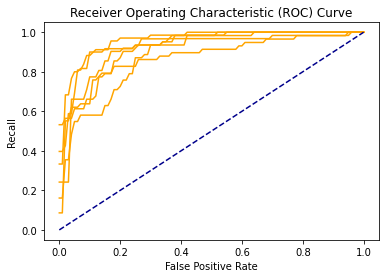

In [47]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('Recall')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    # plt.legend()
    plt.show()

plot_roc_curve(fprs, recalls)

/var/folders/04/2q4w_vgn0_7dtkxyll6j2gx40000gn/T/ipykernel_31782/3654434114.py:22: UserWarning: 
The palette list has fewer values (1) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data = roc, x = 'value_x', y = 'value_y', hue = 'variable', palette = sns.color_palette(['black']), linewidth = 2, alpha = 0.2)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


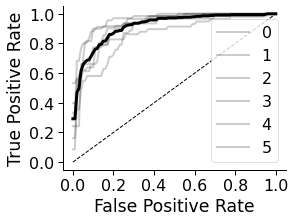

In [50]:
# rename columns of fprs and recalls to subject IDs that are increasing from 0
fprs.columns = np.arange(0, len(fprs.columns))
recalls.columns = np.arange(0, len(recalls.columns))

# wide to long format fprs and recalls and add column for subject IDs
fprs_long = pd.melt(fprs.reset_index(), id_vars=['index'], value_vars=fprs.columns)
recalls_long = pd.melt(recalls.reset_index(), id_vars=['index'], value_vars=recalls.columns)

# merge fprs and recalls
roc = pd.merge(fprs_long, recalls_long, on=['index', 'variable'])

roc_agg = roc.groupby(['value_x']).mean().reset_index()

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(4,3))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True
    
    ax = sns.lineplot(data = roc, x = 'value_x', y = 'value_y', hue = 'variable', palette = sns.color_palette(['black']), linewidth = 2, alpha = 0.2)
    ax = sns.lineplot(data = roc_agg, x = 'value_x', y = 'value_y', color = 'black', linewidth = 3)

    # add a solid diagonal line
    ax.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

    # add a vertical line at 0.15
    # ax.plot([0.15, .15], [0, 1.05], color='black', lw=1, linestyle='--')
    
    # Label and show
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    ax.set_ylabel('True Positive Rate')
    ax.set_xlabel('False Positive Rate')

    # plt.show()
    fig.savefig(path+os.sep+'roc' +'.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    # fig.savefig('results/'+title + '_' +'.png', format='png', transparent=True, bbox_inches='tight', dpi=300)